# Grokking with different activations — modular addition & S_n

The original grokking experiments are extended with:
1. Different activation function (ReLU, quadratic, GELU, tanh)
2. Power spectra analysis for the quadratic activation — both for modular addition (standard FFT) and for the symmetric group.

**Why quadratic?** For modular addition, quadratic activations we have: $(\cos\theta_a + \cos\theta_b)^2$ that expands into products of cosines that directly implement angle addition. For $S_n$, Chughtai–Chan–Nanda ("A Toy Model of Universality") argued that networks represent group multiplication via irreducible representations, and quadratic activations make the irrep structure cleaner.

Also changed where the activation was implemented for easier relabeling the results and the training loop in a function.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import math

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cpu


## Part 1 — Modular addition with configurable activation

### Data creation

In [2]:
def data_create(p: int, frac: float, device, pair_seed: int | None = None):
    X_pairs = torch.cartesian_prod(
        torch.arange(p, device=device),
        torch.arange(p, device=device)
    )
    Y = (X_pairs[:, 0] + X_pairs[:, 1]) % p
    X = F.one_hot(X_pairs, num_classes=p).float()

    n = X.shape[0]
    n_train = int(frac * n)

    if pair_seed is None:
        perm = torch.randperm(n, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(n, generator=g, device=device)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    return {
        "X_pairs": X_pairs,
        "Y": Y,
        "X_train": X[train_idx],
        "Y_train": Y[train_idx],
        "X_test": X[test_idx],
        "Y_test": Y[test_idx],
        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }

### MLP with configurable activation

In [3]:
class MLP(nn.Module):
    def __init__(self, in_size, hid_size, out_size, activation='relu'):
        super(MLP, self).__init__()

        self.in_size = in_size
        self.hid_size = hid_size
        self.out_size = out_size
        self.activation_name = activation

        self.fc1 = nn.Linear(in_size, hid_size, bias=False)
        self.fc2 = nn.Linear(hid_size, out_size, bias=False)

        # standard init
        torch.nn.init.normal_(self.fc1.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3))
        torch.nn.init.normal_(self.fc2.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3))

    def _act(self, x):
        if self.activation_name == 'relu':
            return F.relu(x)
        elif self.activation_name in ('quadratic', 'quad'):
            return x * x
        elif self.activation_name == 'gelu':
            return F.gelu(x)
        elif self.activation_name == 'tanh':
            return torch.tanh(x)
        elif self.activation_name in ('silu', 'swish'):
            return F.silu(x)
        else:
            raise ValueError(f"unknown activation: {self.activation_name}")

    def forward(self, x):
        x = x.flatten(1)
        x = self.fc2(self._act(self.fc1(x)))
        return x

### Training loop, wrapped as a function

Note: with quadratic activation the outputs aren't bounded and aren't sparse, so things can blow up. Lower lr helps.

In [4]:
def train_mod_add(activation, p=97, frac=0.3, hid_size=512, n_epochs=30000,
                  lr=1e-3, weight_decay=0.5, pair_seed=420, verbose=True):
    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)

    data = data_create(p, frac, device, pair_seed=pair_seed)

    model = MLP(in_size=2*p, hid_size=hid_size, out_size=p, activation=activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = torch.empty(n_epochs, device=device)
    test_losses = torch.empty(n_epochs, device=device)
    train_accs = torch.empty(n_epochs, device=device)
    test_accs = torch.empty(n_epochs, device=device)

    X_train = data['X_train'].float()
    Y_train = data['Y_train']
    X_test = data['X_test'].float()
    Y_test = data['Y_test']

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_train)
            test_logits = model(X_test)
            train_losses[epoch] = criterion(train_logits, Y_train)
            test_losses[epoch] = criterion(test_logits, Y_test)
            train_accs[epoch] = (train_logits.argmax(1) == Y_train).float().mean()
            test_accs[epoch] = (test_logits.argmax(1) == Y_test).float().mean()

        if verbose and (epoch + 1) % 2000 == 0:
            print(f"[{activation}] Epoch {epoch+1:6d}/{n_epochs} | "
                  f"train_loss={train_losses[epoch].item():.6f} | "
                  f"test_loss={test_losses[epoch].item():.4f} | "
                  f"test_acc={test_accs[epoch].item():.4f}")

    return {
        'model': model,
        'data': data,
        'p': p,
        'activation': activation,
        'train_losses': train_losses.detach().cpu(),
        'test_losses': test_losses.detach().cpu(),
        'train_accs': train_accs.detach().cpu(),
        'test_accs': test_accs.detach().cpu(),
    }

In [5]:
# ReLU baseline (same as before)
res_relu = train_mod_add('relu', n_epochs=30000, lr=1e-3, weight_decay=0.5)

[relu] Epoch   2000/30000 | train_loss=0.012659 | test_loss=8.5298 | test_acc=0.0000
[relu] Epoch   4000/30000 | train_loss=0.003670 | test_loss=7.5906 | test_acc=0.0000
[relu] Epoch   6000/30000 | train_loss=0.001247 | test_loss=6.3660 | test_acc=0.0024
[relu] Epoch   8000/30000 | train_loss=0.000451 | test_loss=5.1323 | test_acc=0.0269
[relu] Epoch  10000/30000 | train_loss=0.000169 | test_loss=3.9609 | test_acc=0.1110
[relu] Epoch  12000/30000 | train_loss=0.000065 | test_loss=2.8776 | test_acc=0.2774
[relu] Epoch  14000/30000 | train_loss=0.000027 | test_loss=1.8182 | test_acc=0.5163
[relu] Epoch  16000/30000 | train_loss=0.000012 | test_loss=0.9397 | test_acc=0.7692
[relu] Epoch  18000/30000 | train_loss=0.000007 | test_loss=0.4141 | test_acc=0.9214
[relu] Epoch  20000/30000 | train_loss=0.000004 | test_loss=0.1795 | test_acc=0.9778
[relu] Epoch  22000/30000 | train_loss=0.000004 | test_loss=0.0875 | test_acc=0.9927
[relu] Epoch  24000/30000 | train_loss=0.000003 | test_loss=0.049

In [6]:
# Quadratic activation — use smaller lr because x^2 outputs are unbounded
res_quad = train_mod_add('quadratic', n_epochs=30000, lr=3e-4, weight_decay=0.5)

[quadratic] Epoch   2000/30000 | train_loss=0.016100 | test_loss=4.5096 | test_acc=0.0425
[quadratic] Epoch   4000/30000 | train_loss=0.003924 | test_loss=3.1894 | test_acc=0.2458
[quadratic] Epoch   6000/30000 | train_loss=0.001141 | test_loss=1.9860 | test_acc=0.5468
[quadratic] Epoch   8000/30000 | train_loss=0.000371 | test_loss=1.2473 | test_acc=0.7311
[quadratic] Epoch  10000/30000 | train_loss=0.000130 | test_loss=0.8246 | test_acc=0.8307
[quadratic] Epoch  12000/30000 | train_loss=0.000048 | test_loss=0.5399 | test_acc=0.8963
[quadratic] Epoch  14000/30000 | train_loss=0.000019 | test_loss=0.3113 | test_acc=0.9449
[quadratic] Epoch  16000/30000 | train_loss=0.000008 | test_loss=0.1369 | test_acc=0.9831
[quadratic] Epoch  18000/30000 | train_loss=0.000004 | test_loss=0.0412 | test_acc=0.9982
[quadratic] Epoch  20000/30000 | train_loss=0.000002 | test_loss=0.0092 | test_acc=0.9998
[quadratic] Epoch  22000/30000 | train_loss=0.000002 | test_loss=0.0022 | test_acc=1.0000
[quadratic

### Compare training curves

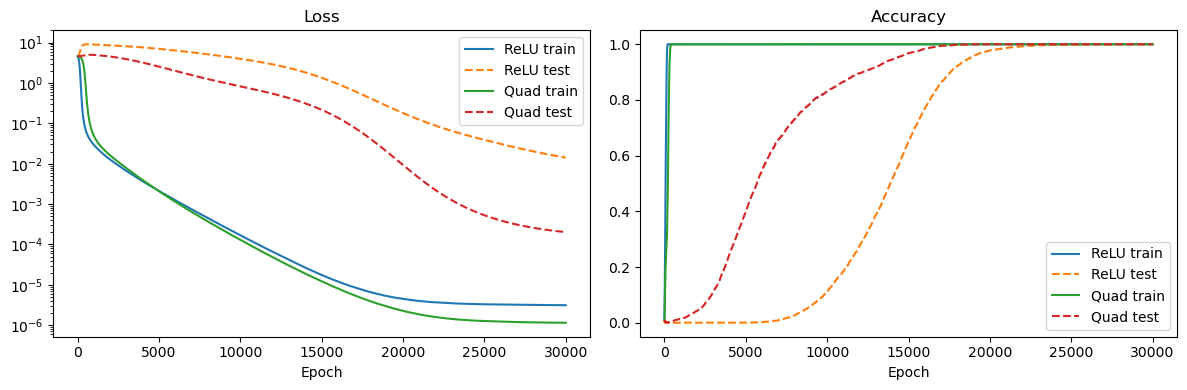

In [7]:
def plot_curves(results_dict):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, res in results_dict.items():
        epochs = torch.arange(len(res['train_losses']))
        axes[0].plot(epochs, res['train_losses'], label=f'{name} train')
        axes[0].plot(epochs, res['test_losses'], label=f'{name} test', linestyle='--')
        axes[1].plot(epochs, res['train_accs'], label=f'{name} train')
        axes[1].plot(epochs, res['test_accs'], label=f'{name} test', linestyle='--')
    axes[0].set_yscale('log')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_curves({'ReLU': res_relu, 'Quad': res_quad})

### Power spectra for both activations

For modular addition, the FFT of the first-layer weights should show isolated peaks at a few key frequencies once the network has grokked. With quadratic activation these peaks are typically cleaner.

=== ReLU ===


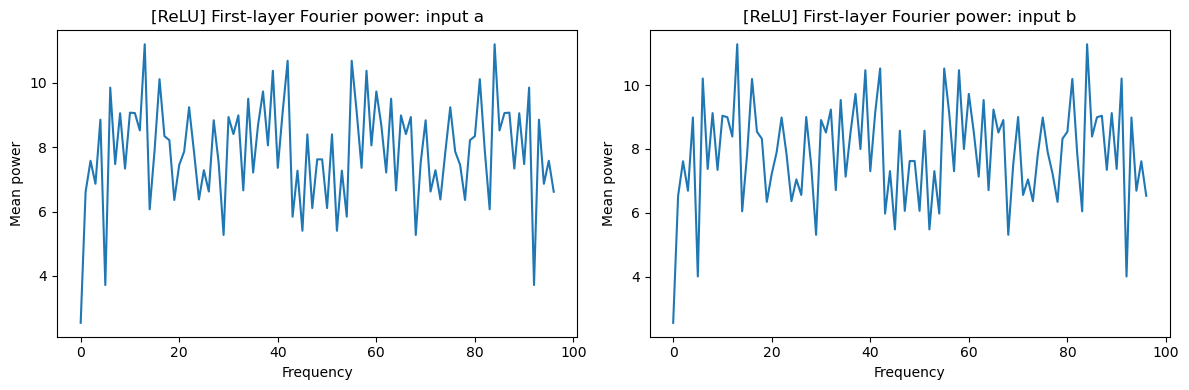

=== Quadratic ===


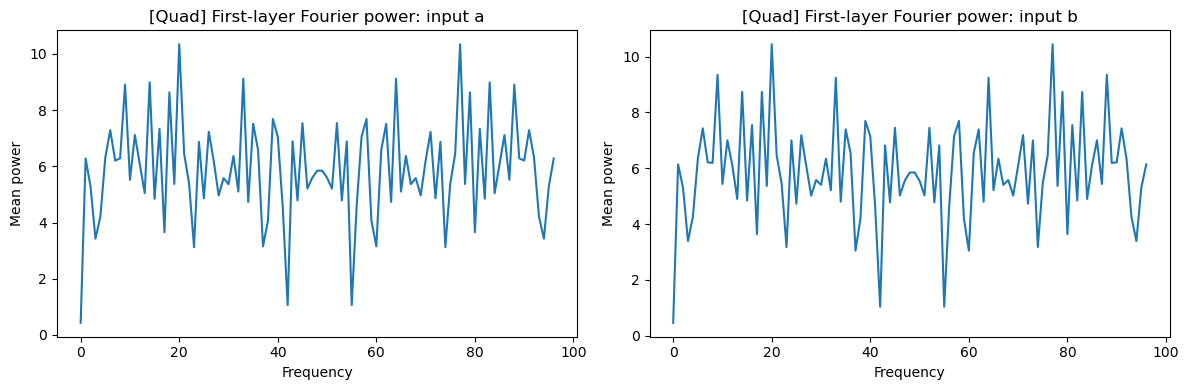

In [8]:
def plot_first_layer_fourier(res, title_prefix=''):
    p = res['p']
    W1 = res['model'].fc1.weight.detach().cpu()
    Wa = W1[:, :p]
    Wb = W1[:, p:]

    Fa = torch.fft.fft(Wa, dim=1)
    Fb = torch.fft.fft(Wb, dim=1)
    power_a = (Fa.abs() ** 2).mean(dim=0)
    power_b = (Fb.abs() ** 2).mean(dim=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(power_a.numpy())
    axes[0].set_title(f"{title_prefix}First-layer Fourier power: input a")
    axes[0].set_xlabel("Frequency"); axes[0].set_ylabel("Mean power")
    axes[1].plot(power_b.numpy())
    axes[1].set_title(f"{title_prefix}First-layer Fourier power: input b")
    axes[1].set_xlabel("Frequency"); axes[1].set_ylabel("Mean power")
    plt.tight_layout(); plt.show()
    return power_a, power_b

print("=== ReLU ===")
_ = plot_first_layer_fourier(res_relu, title_prefix='[ReLU] ')
print("=== Quadratic ===")
_ = plot_first_layer_fourier(res_quad, title_prefix='[Quad] ')

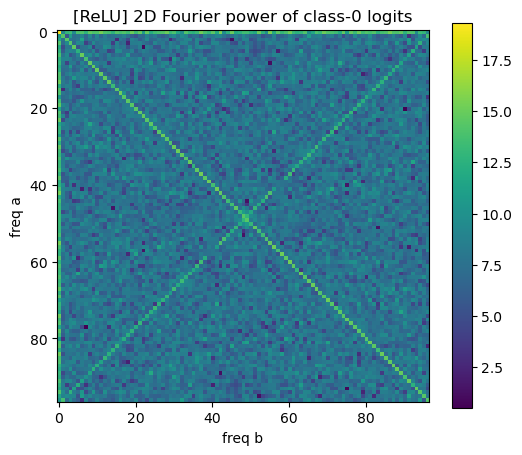

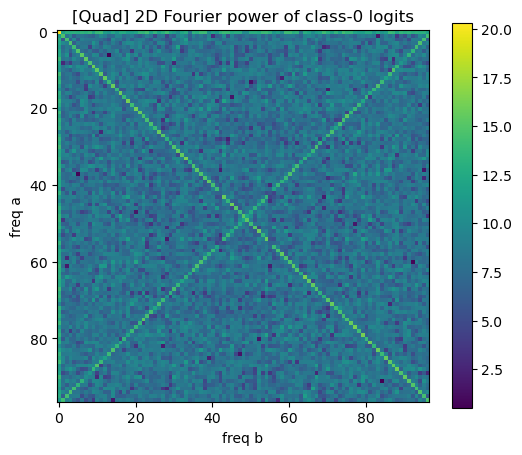

In [9]:
def plot_2d_logit_spectrum(res, output_class=0, title_prefix=''):
    p = res['p']
    model = res['model']
    with torch.no_grad():
        X_pairs = torch.cartesian_prod(torch.arange(p, device=device),
                                        torch.arange(p, device=device))
        X_full = F.one_hot(X_pairs, num_classes=p).float()
        logits = model(X_full).cpu()
    logit_c = logits[:, output_class].reshape(p, p)
    F2 = torch.fft.fft2(logit_c)
    power2 = (F2.abs() ** 2)

    plt.figure(figsize=(6, 5))
    plt.imshow(torch.log1p(power2).numpy(), cmap='viridis')
    plt.colorbar()
    plt.title(f"{title_prefix}2D Fourier power of class-{output_class} logits")
    plt.xlabel("freq b"); plt.ylabel("freq a")
    plt.show()

plot_2d_logit_spectrum(res_relu, title_prefix='[ReLU] ')
plot_2d_logit_spectrum(res_quad, title_prefix='[Quad] ')

### Single-neuron inspection

Pick a neuron and look at its weights + FFT. Under quadratic activation, an individual neuron typically latches onto a single frequency cleanly.

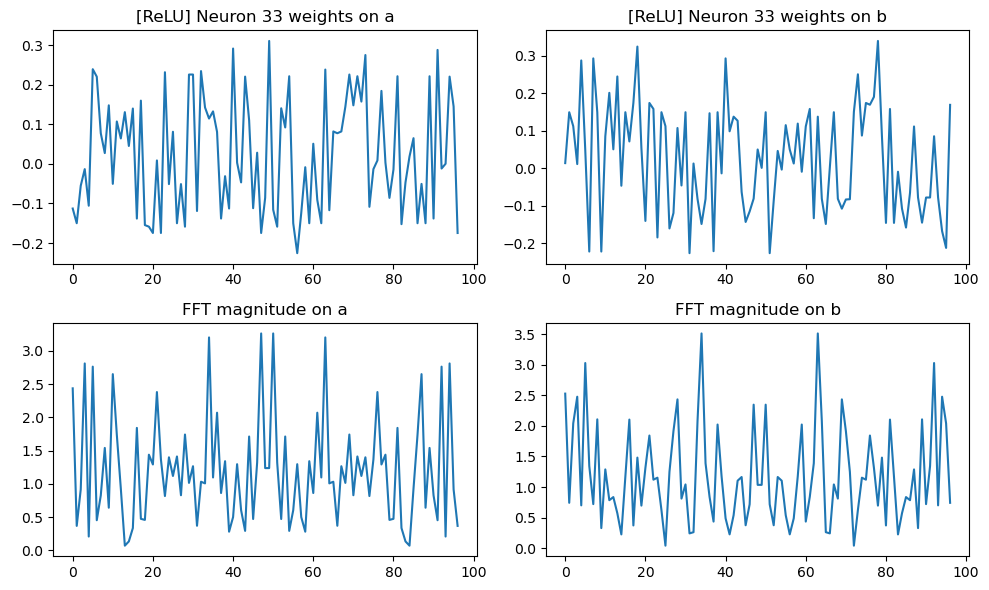

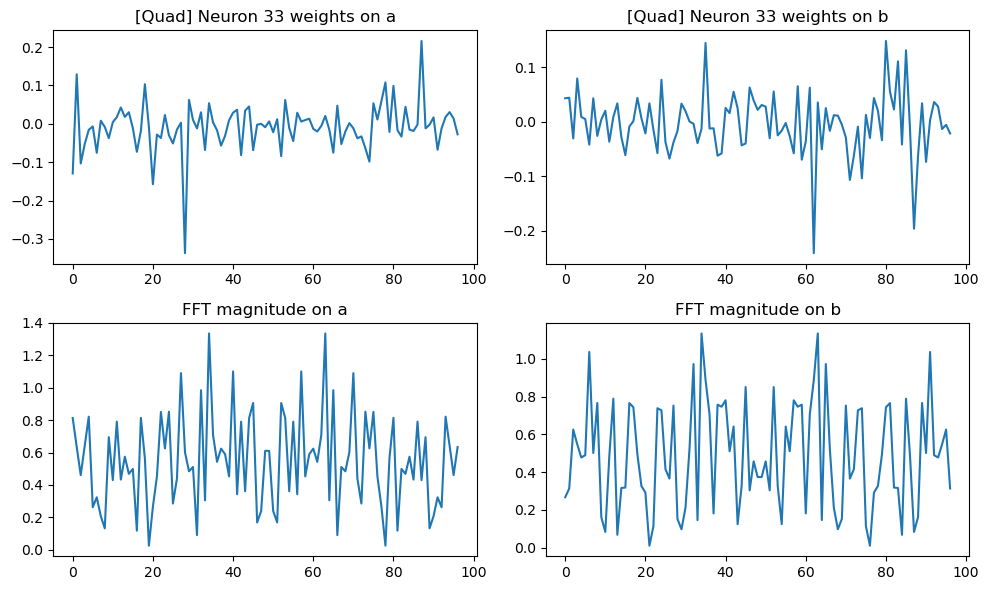

In [10]:
def plot_neuron(res, k=33, title_prefix=''):
    p = res['p']
    W1 = res['model'].fc1.weight.detach().cpu()
    Wa = W1[:, :p]; Wb = W1[:, p:]
    Fa = torch.fft.fft(Wa, dim=1); Fb = torch.fft.fft(Wb, dim=1)

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes[0, 0].plot(Wa[k].numpy()); axes[0, 0].set_title(f"{title_prefix}Neuron {k} weights on a")
    axes[0, 1].plot(Wb[k].numpy()); axes[0, 1].set_title(f"{title_prefix}Neuron {k} weights on b")
    axes[1, 0].plot(Fa[k].abs().numpy()); axes[1, 0].set_title("FFT magnitude on a")
    axes[1, 1].plot(Fb[k].abs().numpy()); axes[1, 1].set_title("FFT magnitude on b")
    plt.tight_layout(); plt.show()

plot_neuron(res_relu, k=33, title_prefix='[ReLU] ')
plot_neuron(res_quad, k=33, title_prefix='[Quad] ')

## Part 2 — Symmetric group $S_n$

### Group utilities

In [11]:
from sympy.combinatorics.named_groups import SymmetricGroup as SymPySymmetricGroup
from sympy.combinatorics import Permutation, PermutationGroup

class symmgr():
    def __init__(self, n: int, device):
        self.g = SymPySymmetricGroup(n)
        self.n = n
        self.device = device
        self.elements = list(self.g.generate_schreier_sims())
        self.order = len(self.elements)
        self.multiplication_table = self.compute_multiplication_table()
        self.identity = [i for i in range(self.order) if self.idx_to_perm(i).order() == 1][0]

    def idx_to_perm(self, x):
        return self.elements[x]

    def perm_to_idx(self, perm):
        return self.elements.index(perm)

    def compute_signatures(self, x):
        return self.idx_to_perm(x).signature()

    def compute_inverses(self, x):
        return (self.multiplication_table[x, :] == self.identity).nonzero().item()

    def compose(self, x, y):
        return self.perm_to_idx(self.idx_to_perm(x) * self.idx_to_perm(y))

    def compute_multiplication_table(self):
        table = torch.zeros((self.order, self.order), dtype=torch.int64, device=self.device)
        for i in range(self.order):
            for j in range(self.order):
                table[i, j] = self.compose(i, j)
        return table


def data_create_sym(n: int, frac: float, device, pair_seed: int | None = None):
    grp = symmgr(n, device)
    idx = torch.arange(grp.order, device=device)
    X = torch.cartesian_prod(idx, idx)
    Y = torch.tensor([grp.compose(i.item(), j.item()) for i, j in X], device=device)

    if pair_seed is None:
        perm = torch.randperm(grp.order * grp.order, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(grp.order * grp.order, generator=g, device=device)

    N = X.shape[0]
    N_train = int(frac * N)
    train_idx = perm[:N_train]
    test_idx = perm[N_train:]

    return {
        'X': X[perm], 'Y': Y[perm],
        'X_train': X[train_idx], 'Y_train': Y[train_idx],
        'X_test': X[test_idx], 'Y_test': Y[test_idx],
        'grp': grp
    }

### Perm-MLP with configurable activation

In [12]:
class PermMLP(nn.Module):
    def __init__(self, in_size, embed_size, hid_size, out_size, activation='relu'):
        super(PermMLP, self).__init__()
        self.in_size = in_size
        self.out_size = out_size
        self.hid_size = hid_size
        self.embed_size = embed_size
        self.activation_name = activation

        self.El = nn.Embedding(in_size, embed_size)
        self.W = nn.Linear(2 * embed_size, hid_size, bias=False)
        self.Er = nn.Embedding(in_size, embed_size)
        self.U = nn.Linear(hid_size, out_size, bias=False)

        nn.init.xavier_normal_(self.El.weight)
        nn.init.xavier_normal_(self.W.weight)
        nn.init.xavier_normal_(self.Er.weight)
        nn.init.xavier_normal_(self.U.weight)

    def _act(self, x):
        if self.activation_name == 'relu':
            return F.relu(x)
        elif self.activation_name in ('quadratic', 'quad'):
            return x * x
        elif self.activation_name == 'gelu':
            return F.gelu(x)
        elif self.activation_name == 'tanh':
            return torch.tanh(x)
        elif self.activation_name in ('silu', 'swish'):
            return F.silu(x)
        else:
            raise ValueError(f"unknown activation: {self.activation_name}")

    def forward(self, xl, xr):
        w = torch.cat([self.El(xl), self.Er(xr)], dim=1)
        w = self.U(self._act(self.W(w)))
        return w

In [13]:
def train_perm_model(activation, n=5, frac=0.3, hid_size=128, embed_size=256,
                     n_epochs=30000, lr=1e-3, weight_decay=1.0, pair_seed=420, verbose=True):
    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)

    in_size = math.factorial(n)
    out_size = in_size

    data = data_create_sym(n, frac, device, pair_seed)

    model = PermMLP(in_size=in_size, embed_size=embed_size,
                    hid_size=hid_size, out_size=out_size,
                    activation=activation).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = torch.empty(n_epochs, device=device)
    test_losses = torch.empty(n_epochs, device=device)
    train_accs = torch.empty(n_epochs, device=device)
    test_accs = torch.empty(n_epochs, device=device)

    Xl_train = data['X_train'][:, 0].long()
    Xr_train = data['X_train'][:, 1].long()
    Y_train = data['Y_train'].long()
    Xl_test = data['X_test'][:, 0].long()
    Xr_test = data['X_test'][:, 1].long()
    Y_test = data['Y_test'].long()

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(Xl_train, Xr_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(Xl_train, Xr_train)
            test_logits = model(Xl_test, Xr_test)
            train_losses[epoch] = criterion(train_logits, Y_train)
            test_losses[epoch] = criterion(test_logits, Y_test)
            train_accs[epoch] = (train_logits.argmax(1) == Y_train).float().mean()
            test_accs[epoch] = (test_logits.argmax(1) == Y_test).float().mean()

        if verbose and (epoch + 1) % 2000 == 0:
            print(f"[{activation}] Epoch {epoch+1:6d}/{n_epochs} | "
                  f"train_loss={train_losses[epoch].item():.6f} | "
                  f"test_loss={test_losses[epoch].item():.4f} | "
                  f"test_acc={test_accs[epoch].item():.4f}")

    return {
        'model': model,
        'data': data,
        'n': n,
        'activation': activation,
        'train_losses': train_losses.detach().cpu(),
        'test_losses': test_losses.detach().cpu(),
        'train_accs': train_accs.detach().cpu(),
        'test_accs': test_accs.detach().cpu(),
    }

In [14]:
# ReLU baseline
res_perm_relu = train_perm_model('relu', n=5, n_epochs=30000, lr=1e-3, weight_decay=1.0)

[relu] Epoch   2000/30000 | train_loss=0.017873 | test_loss=15.8922 | test_acc=0.0006
[relu] Epoch   4000/30000 | train_loss=0.005627 | test_loss=16.9947 | test_acc=0.0003
[relu] Epoch   6000/30000 | train_loss=0.002123 | test_loss=17.8437 | test_acc=0.0003
[relu] Epoch   8000/30000 | train_loss=0.000825 | test_loss=17.7414 | test_acc=0.0009
[relu] Epoch  10000/30000 | train_loss=0.000333 | test_loss=18.3824 | test_acc=0.0006
[relu] Epoch  12000/30000 | train_loss=0.000135 | test_loss=18.4485 | test_acc=0.0007
[relu] Epoch  14000/30000 | train_loss=0.000058 | test_loss=19.2564 | test_acc=0.0013
[relu] Epoch  16000/30000 | train_loss=0.000026 | test_loss=19.9479 | test_acc=0.0011
[relu] Epoch  18000/30000 | train_loss=0.000014 | test_loss=20.4331 | test_acc=0.0015
[relu] Epoch  20000/30000 | train_loss=0.000008 | test_loss=20.6584 | test_acc=0.0018
[relu] Epoch  22000/30000 | train_loss=0.000006 | test_loss=20.7023 | test_acc=0.0019
[relu] Epoch  24000/30000 | train_loss=0.000005 | test

In [15]:
# Quadratic activation
res_perm_quad = train_perm_model('quadratic', n=5, n_epochs=30000, lr=3e-4, weight_decay=1.0)

[quadratic] Epoch   2000/30000 | train_loss=0.008526 | test_loss=15.9727 | test_acc=0.0018
[quadratic] Epoch   4000/30000 | train_loss=0.002252 | test_loss=16.8282 | test_acc=0.0023
[quadratic] Epoch   6000/30000 | train_loss=0.000710 | test_loss=17.8316 | test_acc=0.0034
[quadratic] Epoch   8000/30000 | train_loss=0.000242 | test_loss=18.8932 | test_acc=0.0046
[quadratic] Epoch  10000/30000 | train_loss=0.000087 | test_loss=19.9711 | test_acc=0.0048
[quadratic] Epoch  12000/30000 | train_loss=0.000032 | test_loss=21.0293 | test_acc=0.0043
[quadratic] Epoch  14000/30000 | train_loss=0.000012 | test_loss=22.0112 | test_acc=0.0047
[quadratic] Epoch  16000/30000 | train_loss=0.000005 | test_loss=22.8036 | test_acc=0.0063
[quadratic] Epoch  18000/30000 | train_loss=0.000002 | test_loss=23.2881 | test_acc=0.0068
[quadratic] Epoch  20000/30000 | train_loss=0.000001 | test_loss=23.4673 | test_acc=0.0074
[quadratic] Epoch  22000/30000 | train_loss=0.000001 | test_loss=23.4215 | test_acc=0.0075

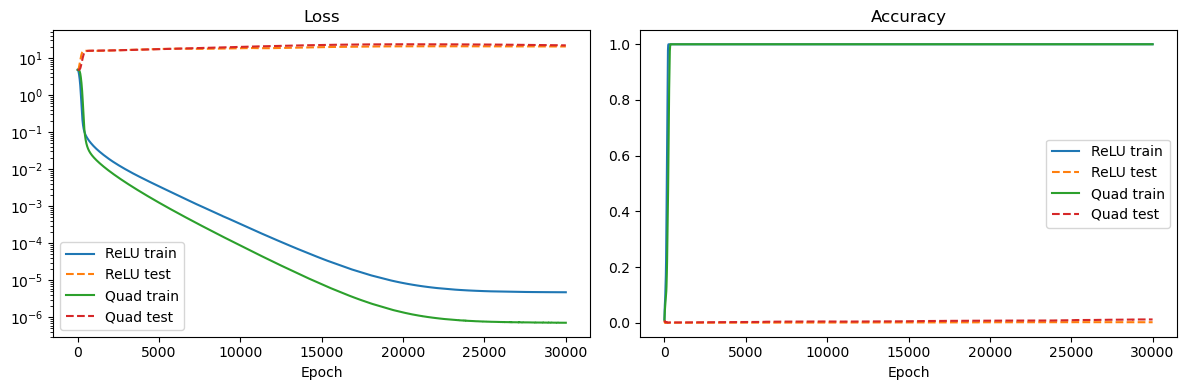

In [16]:
plot_curves({'ReLU': res_perm_relu, 'Quad': res_perm_quad})

Breakdown of the previous case

- The weights going into a single neuron from the left embedding still form a vector in $$ℝ^|G| = ℝ^120$$, indexed by group elements: w ∈ ℝ^120.
- S_5 has 7 irreps of dimensions 1, 4, 5, 6, 5, 4, 1. They are not 1-dimensional.
- The group Fourier transform of w is
w^(ρ)=∑g∈S5w(g) ρ(g)\hat w(\rho) = \sum_{g \in S_5} w(g) \, \rho(g)w^(ρ)=g∈S5​∑​w(g)ρ(g)

For the trivial rep this is a scalar. 
For the standard rep (4,1) this is a 4×4 matrix. 
For (3,1,1) it's a 6×6 matrix. 
Instead of 120 scalars, we get 7 matrices of varying sizes, containing ∑dρ2=120\sum d_\rho^2 = 120
∑dρ2​=120 real numbers total.


---

# Part 3 — Full GCR analysis on $S_5$

Reproduction of the main analysis from Chughtai-Chan-Nanda, *"A Toy Model of Universality"*. The goal: verify that the network implements group composition via representations (the "GCR algorithm").

This part uses a richer `Symmgr` class (with precomputed multiplication and inverse tables) and builds full matrix irreps via Young's orthogonal form — needed for the FVE and ablation analyses below. The `PermMLP` is retrained here with the paper's hyperparameters (250k epochs, weight decay 1), independently of the Part 2 models.


## 1. Building matrix irreps of $S_n$ via Young's orthogonal form

Build first the matrix irreps.
 Irreps of $S_n$ are indexed by **partitions** of $n$; for each partition $\lambda$, the irrep has dimension equal to the number of **standard Young tableaux** (SYTs) of shape $\lambda$.

The **Young orthogonal form** gives matrix irreps $\rho^\lambda$ satisfying $\rho^\lambda(\sigma)$ is orthogonal for every $\sigma$, which is what we want (the paper uses real orthogonal matrices). 

The construction:

- Enumerate all SYTs of shape $\lambda$. These index the basis of the irrep.
- For each adjacent transposition $s_k = (k, k+1)$, give the matrix $\rho^\lambda(s_k)$ explicitly in the SYT basis using axial distances (see Sagan, *The Symmetric Group*, Thm 3.14.2).
- For a general permutation $\sigma$, write it as a product of adjacent transpositions and multiply.


In [17]:
def partitions(n):
    """All partitions of n as weakly-decreasing tuples."""
    if n == 0:
        return [()]
    out = []
    def rec(remaining, max_part, current):
        if remaining == 0:
            out.append(tuple(current))
            return
        for k in range(min(remaining, max_part), 0, -1):
            rec(remaining - k, k, current + [k])
    rec(n, n, [])
    return out

def standard_young_tableaux(shape):
    """Enumerate all SYT of the given shape (a partition).

    Each SYT is returned as a tuple of rows, each row a tuple of entries.
    Entries are 1..n, increasing left-to-right in each row and top-to-bottom
    in each column.
    """
    n = sum(shape)
    nrows = len(shape)
    # Build tableaux by placing 1, 2, ..., n in turn. At each step the set
    # of valid cells is the inner corners of the current partial shape.
    results = []
    rows = [[] for _ in range(nrows)]

    def rec(k):
        if k > n:
            results.append(tuple(tuple(r) for r in rows))
            return
        for i in range(nrows):
            if len(rows[i]) < shape[i] and (i == 0 or len(rows[i]) < len(rows[i-1])):
                rows[i].append(k)
                rec(k + 1)
                rows[i].pop()

    rec(1)
    return results

# quick sanity check
for lam in partitions(5):
    print(f"partition {lam}: {len(standard_young_tableaux(lam))} SYTs")
# expected dims for S_5: (5)->1, (4,1)->4, (3,2)->5, (3,1,1)->6, (2,2,1)->5, (2,1,1,1)->4, (1,1,1,1,1)->1

partition (5,): 1 SYTs
partition (4, 1): 4 SYTs
partition (3, 2): 5 SYTs
partition (3, 1, 1): 6 SYTs
partition (2, 2, 1): 5 SYTs
partition (2, 1, 1, 1): 4 SYTs
partition (1, 1, 1, 1, 1): 1 SYTs


In [18]:
def tableau_position(T, k):
    """Return (row, col) of entry k in tableau T. Both zero-indexed."""
    for i, row in enumerate(T):
        for j, val in enumerate(row):
            if val == k:
                return (i, j)
    raise ValueError(f"{k} not found")

def axial_distance(T, k):
    """Signed axial distance from k to k+1 in tableau T: (col_{k+1} - row_{k+1}) - (col_k - row_k).
    
    This is the content of cell(k+1) minus the content of cell(k).
    """
    r1, c1 = tableau_position(T, k)
    r2, c2 = tableau_position(T, k+1)
    return (c2 - r2) - (c1 - r1)

def swap_k_kp1(T, k):
    """Return a new tableau with entries k and k+1 swapped, if result is still standard.
    Returns None if the swap produces a non-standard tableau (i.e. k, k+1 are in same row or column).
    """
    r1, c1 = tableau_position(T, k)
    r2, c2 = tableau_position(T, k+1)
    if r1 == r2 or c1 == c2:
        return None  # same row/column: swap would violate standardness
    new_T = tuple(
        tuple(
            (k+1 if v == k else (k if v == k+1 else v))
            for v in row
        )
        for row in T
    )
    return new_T

In [19]:
def young_orthogonal_irrep(shape):
    """Return a function rho: permutation-as-tuple -> orthogonal matrix.

    Construction: For each adjacent transposition s_k = (k, k+1), we define
    rho(s_k) in the SYT basis via the Young orthogonal form:

      - If k and k+1 are in the same row of T, rho(s_k) T = +T.
      - If k and k+1 are in the same column of T, rho(s_k) T = -T.
      - Otherwise let d = axial distance from k to k+1 in T, rho = 1/d,
        and T' = T with k, k+1 swapped. Then:
          rho(s_k) T  = rho * T + sqrt(1 - rho^2) * T'
          rho(s_k) T' = sqrt(1 - rho^2) * T - rho * T'

    A general permutation is written as a product of adjacent transpositions
    and we multiply the matrices.
    """
    tableaux = standard_young_tableaux(shape)
    d = len(tableaux)
    t_index = {T: i for i, T in enumerate(tableaux)}
    n = sum(shape)

    # Precompute rho(s_k) for k = 1, ..., n-1
    adjacent_mats = []
    for k in range(1, n):
        M = np.zeros((d, d))
        for T in tableaux:
            i = t_index[T]
            r1, c1 = tableau_position(T, k)
            r2, c2 = tableau_position(T, k+1)
            if r1 == r2:       # same row
                M[i, i] = 1.0
            elif c1 == c2:     # same column
                M[i, i] = -1.0
            else:
                dist = (c2 - r2) - (c1 - r1)
                rho_val = 1.0 / dist
                M[i, i] = rho_val
                T_swapped = swap_k_kp1(T, k)
                if T_swapped is not None and T_swapped in t_index:
                    j = t_index[T_swapped]
                    M[i, j] = math.sqrt(max(0.0, 1.0 - rho_val ** 2))
        adjacent_mats.append(M)

    def decompose_to_adjacent(perm_tuple):
        """Given a permutation as a tuple (0-indexed one-line notation),
        return a list of adjacent transposition indices k (meaning s_k = (k, k+1), 1-indexed)
        whose product equals perm. Uses bubble-sort decomposition."""
        arr = list(perm_tuple)
        ops = []
        # we want: applying s_{k_1} s_{k_2} ... s_{k_m} to identity gives perm.
        # Equivalently, sorting perm via adjacent swaps recorded in reverse.
        a = arr[:]
        swap_list = []
        # sort `a` to identity [0,1,...,n-1] via adjacent transpositions, record them
        nn = len(a)
        for i in range(nn):
            # find position of i
            pos = a.index(i)
            while pos > i:
                a[pos], a[pos-1] = a[pos-1], a[pos]
                swap_list.append(pos)  # this is the index k in 0-indexed swap of (k-1, k)
                pos -= 1
        # swap_list contains the swaps that sort `perm` to identity.
        # To reconstruct perm from identity we apply them in reverse order.
        return list(reversed(swap_list))

    def rho(perm_tuple):
        ops = decompose_to_adjacent(perm_tuple)
        M = np.eye(d)
        # perm = s_{ops[0]} * s_{ops[1]} * ... * s_{ops[-1]} in sympy's convention
        # so rho(perm) = rho(s_{ops[0]}) @ rho(s_{ops[1]}) @ ... @ rho(s_{ops[-1]})
        for k_zero_indexed in ops:
            M = M @ adjacent_mats[k_zero_indexed - 1]
        return M

    return rho, d, tableaux

In [20]:
# checks
rho_std_3, d_std_3, _ = young_orthogonal_irrep((2, 1))  # standard rep of S_3, dimension 2
print("dim standard of S_3:", d_std_3)

id3 = (0, 1, 2)
s1 = (1, 0, 2)          # (1 2)
s2 = (0, 2, 1)          # (2 3)
cyclic = (1, 2, 0)      # (1 2 3) = s_1 s_2 (one-line: sends 0->1, 1->2, 2->0)

print("rho(id):\n", rho_std_3(id3))
print("rho(s_1):\n", rho_std_3(s1))
print("rho(s_2):\n", rho_std_3(s2))
print("rho(s_1)@rho(s_2):\n", rho_std_3(s1) @ rho_std_3(s2))
print("rho(s_1 s_2 applied):", rho_std_3(cyclic))

# Homomorphism check
def compose_perm(p, q):
    """(p composed with q)[i] = p[q[i]]. Matches sympy's Permutation * convention."""
    return tuple(p[q[i]] for i in range(len(p)))

M1 = rho_std_3(s1)
M2 = rho_std_3(s2)
Mprod = rho_std_3(compose_perm(s1, s2))
print("Homomorphism error (s_1 * s_2):", np.max(np.abs(M1 @ M2 - Mprod)))

dim standard of S_3: 2
rho(id):
 [[1. 0.]
 [0. 1.]]
rho(s_1):
 [[ 1.  0.]
 [ 0. -1.]]
rho(s_2):
 [[-0.5        0.8660254]
 [ 0.8660254  0.5      ]]
rho(s_1)@rho(s_2):
 [[-0.5        0.8660254]
 [-0.8660254 -0.5      ]]
rho(s_1 s_2 applied): [[-0.5        0.8660254]
 [-0.8660254 -0.5      ]]
Homomorphism error (s_1 * s_2): 0.0


In [21]:
# Wider homomorphism test on S_5 for the standard rep (4,1)
np.random.seed(0)
rho_std_5, d_std_5, _ = young_orthogonal_irrep((4, 1))
print("dim standard of S_5:", d_std_5)

errors = []
for _ in range(50):
    p = tuple(np.random.permutation(5).tolist())
    q = tuple(np.random.permutation(5).tolist())
    Mp = rho_std_5(p); Mq = rho_std_5(q); Mpq = rho_std_5(compose_perm(p, q))
    errors.append(np.max(np.abs(Mp @ Mq - Mpq)))
print("max homomorphism error across 50 random (p,q) pairs on S_5 standard:", max(errors))

dim standard of S_5: 4
max homomorphism error across 50 random (p,q) pairs on S_5 standard: 3.3306690738754696e-16


## 2. Group setup and building an irrep library for $S_n$

Now I wrap the symmgr class from before and extend it with all irreps precomputed. The paper names the irreps of $S_5$ as: *trivial, sign, standard, standard_sign, 5d_a, 5d_b, 6d*. Mapping to partitions:

- trivial = $(5)$, dim 1
- sign = $(1,1,1,1,1)$, dim 1
- standard = $(4,1)$, dim 4
- standard_sign = $(2,1,1,1)$, dim 4
- 5d_a = $(3,2)$, dim 5
- 5d_b = $(2,2,1)$, dim 5
- 6d = $(3,1,1)$, dim 6

In [22]:
IRREP_NAMES_S5 = {
    (5,): 'trivial',
    (1,1,1,1,1): 'sign',
    (4,1): 'standard',
    (2,1,1,1): 'standard_sign',
    (3,2): '5d_a',
    (2,2,1): '5d_b',
    (3,1,1): '6d',
}

class Symmgr:
    def __init__(self, n, device):
        self.n = n
        self.device = device
        self.g = SymPySymmetricGroup(n)
        self.elements = list(self.g.generate_schreier_sims())
        self.order = len(self.elements)

        # store each element as a 0-indexed one-line tuple (so perm_tuple[i] = image of i)
        self._tuples = [tuple(p(i) for i in range(n)) for p in self.elements]
        self._tuple_to_idx = {t: i for i, t in enumerate(self._tuples)}

        # identity index
        id_tuple = tuple(range(n))
        self.identity = self._tuple_to_idx[id_tuple]

        # multiplication and inverse tables
        self.mult_table = torch.zeros((self.order, self.order), dtype=torch.long, device=device)
        self.inv_table = torch.zeros(self.order, dtype=torch.long, device=device)
        for i, pi in enumerate(self._tuples):
            # inverse: inv[pi[i]] = i
            inv = [0] * n
            for k in range(n):
                inv[pi[k]] = k
            self.inv_table[i] = self._tuple_to_idx[tuple(inv)]
            for j, pj in enumerate(self._tuples):
                # compose pi * pj in sympy convention: (pi * pj)(k) = pi(pj(k))
                prod = tuple(pi[pj[k]] for k in range(n))
                self.mult_table[i, j] = self._tuple_to_idx[prod]

    def compose_idx(self, i, j):
        return int(self.mult_table[i, j].item())

    def inverse_idx(self, i):
        return int(self.inv_table[i].item())

    def build_irrep_matrices(self, partition):
        """Return a (|G|, d, d) numpy array of irrep matrices, one per group element."""
        rho_fn, d, _ = young_orthogonal_irrep(partition)
        mats = np.zeros((self.order, d, d))
        for i, t in enumerate(self._tuples):
            mats[i] = rho_fn(t)
        return mats

    def all_irreps(self):
        """Dict {name: (partition, mats of shape (|G|, d, d))} for every irrep."""
        out = {}
        for lam in partitions(self.n):
            name = IRREP_NAMES_S5.get(lam, f'irrep_{lam}')
            out[name] = (lam, self.build_irrep_matrices(lam))
        return out


grp5 = Symmgr(5, device)
print("order:", grp5.order, "identity idx:", grp5.identity)
print("multiplication table shape:", grp5.mult_table.shape)

order: 120 identity idx: 20
multiplication table shape: torch.Size([120, 120])


In [23]:
# Precompute all irreps. This takes a few seconds.
irreps = grp5.all_irreps()
for name, (lam, mats) in irreps.items():
    print(f"{name:16s} partition={lam} dim={mats.shape[1]}")

# Verify sum of d^2 = |G|
total = sum(mats.shape[1] ** 2 for _, mats in irreps.values())
print("sum of d^2:", total, " |G|:", grp5.order)

trivial          partition=(5,) dim=1
standard         partition=(4, 1) dim=4
5d_a             partition=(3, 2) dim=5
6d               partition=(3, 1, 1) dim=6
5d_b             partition=(2, 2, 1) dim=5
standard_sign    partition=(2, 1, 1, 1) dim=4
sign             partition=(1, 1, 1, 1, 1) dim=1
sum of d^2: 120  |G|: 120


## 3. Training the PermMLP on $S_5$ with paper hyperparameters

Hyperparameters from their Appendix C: embedding 256, hidden 128, train fraction 0.4, weight decay $\lambda=1$, AdamW with $\beta_1=0.9, \beta_2=0.98$, lr $10^{-3}$, 250k epochs.

**250k epochs is a lot.** If you're just sanity-checking, drop `n_epochs` to something like 40k to confirm the code runs end-to-end, but know that you won't see full grokking and the FVE numbers will look wrong. Full paper reproduction needs the full run.

In [24]:
def data_create_sym_from_grp(grp, frac, device, pair_seed=420):
    idx = torch.arange(grp.order, device=device)
    X = torch.cartesian_prod(idx, idx)
    Y = grp.mult_table[X[:, 0], X[:, 1]]
    N = X.shape[0]
    g = torch.Generator(device=device).manual_seed(pair_seed)
    perm = torch.randperm(N, generator=g, device=device)
    N_train = int(frac * N)
    return {
        'X_train': X[perm[:N_train]], 'Y_train': Y[perm[:N_train]],
        'X_test':  X[perm[N_train:]], 'Y_test':  Y[perm[N_train:]],
        'grp': grp
    }

class PermMLP_paper(nn.Module):
    def __init__(self, in_size, embed_size, hid_size, out_size):
        super().__init__()
        self.El = nn.Embedding(in_size, embed_size)
        self.Er = nn.Embedding(in_size, embed_size)
        self.W  = nn.Linear(2 * embed_size, hid_size, bias=False)
        self.U  = nn.Linear(hid_size, out_size, bias=False)
        for m in (self.El, self.Er):
            nn.init.xavier_normal_(m.weight)
        for m in (self.W, self.U):
            nn.init.xavier_normal_(m.weight)

    def forward(self, xl, xr, return_hidden=False):
        concat = torch.cat([self.El(xl), self.Er(xr)], dim=1)
        pre = self.W(concat)
        hidden = F.relu(pre)
        logits = self.U(hidden)
        if return_hidden:
            return logits, hidden, pre
        return logits

    def Wa(self):
        """Effective 'left embedding' W_a = W[:, :embed] @ El, shape (hid, |G|)
        following the paper's Appendix C.1."""
        embed = self.El.weight.shape[1]
        W_left = self.W.weight[:, :embed]
        return W_left @ self.El.weight.T  # (hid, |G|)

    def Wb(self):
        embed = self.Er.weight.shape[1]
        W_right = self.W.weight[:, embed:]
        return W_right @ self.Er.weight.T  # (hid, |G|)

    def WU(self):
        return self.U.weight  # (|G|, hid)


def train_gcr(grp, frac=0.4, embed_size=256, hid_size=128,
          n_epochs=250_000, lr=1e-3, wd=1.0, beta1=0.9, beta2=0.98,
          log_every=5000, pair_seed=420):
    torch.manual_seed(0); np.random.seed(0); random.seed(0)
    data = data_create_sym_from_grp(grp, frac, device, pair_seed=pair_seed)
    model = PermMLP_paper(grp.order, embed_size, hid_size, grp.order).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=(beta1, beta2))
    crit = nn.CrossEntropyLoss()

    Xl_tr = data['X_train'][:, 0].long(); Xr_tr = data['X_train'][:, 1].long(); Y_tr = data['Y_train'].long()
    Xl_te = data['X_test'][:, 0].long();  Xr_te = data['X_test'][:, 1].long();  Y_te = data['Y_test'].long()

    losses = {'train': [], 'test': [], 'train_acc': [], 'test_acc': [], 'epoch': []}
    for epoch in range(n_epochs):
        model.train(); opt.zero_grad()
        logits = model(Xl_tr, Xr_tr)
        loss = crit(logits, Y_tr); loss.backward(); opt.step()

        if (epoch + 1) % log_every == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                tr_log = model(Xl_tr, Xr_tr); te_log = model(Xl_te, Xr_te)
                tr_loss = crit(tr_log, Y_tr).item(); te_loss = crit(te_log, Y_te).item()
                tr_acc  = (tr_log.argmax(1) == Y_tr).float().mean().item()
                te_acc  = (te_log.argmax(1) == Y_te).float().mean().item()
            losses['train'].append(tr_loss); losses['test'].append(te_loss)
            losses['train_acc'].append(tr_acc); losses['test_acc'].append(te_acc)
            losses['epoch'].append(epoch + 1)
            print(f"epoch {epoch+1:7d} | tr_loss={tr_loss:.3e} te_loss={te_loss:.3e} tr_acc={tr_acc:.4f} te_acc={te_acc:.4f}")

    return model, data, losses

In [25]:
# SHORT RUN for sanity check. Change to 250_000 for full paper reproduction.
model, data, losses = train_gcr(grp5, frac=0.4, n_epochs=40_000, log_every=2000)

epoch       1 | tr_loss=4.784e+00 te_loss=4.792e+00 tr_acc=0.0089 te_acc=0.0082
epoch    2000 | tr_loss=1.064e-05 te_loss=4.240e+01 tr_acc=1.0000 te_acc=0.0003
epoch    4000 | tr_loss=9.246e-06 te_loss=3.866e+01 tr_acc=1.0000 te_acc=0.0009
epoch    6000 | tr_loss=8.939e-06 te_loss=3.695e+01 tr_acc=1.0000 te_acc=0.0010
epoch    8000 | tr_loss=8.749e-06 te_loss=3.575e+01 tr_acc=1.0000 te_acc=0.0008
epoch   10000 | tr_loss=8.591e-06 te_loss=3.483e+01 tr_acc=1.0000 te_acc=0.0012
epoch   12000 | tr_loss=8.454e-06 te_loss=3.398e+01 tr_acc=1.0000 te_acc=0.0014
epoch   14000 | tr_loss=8.328e-06 te_loss=3.314e+01 tr_acc=1.0000 te_acc=0.0016
epoch   16000 | tr_loss=8.210e-06 te_loss=3.231e+01 tr_acc=1.0000 te_acc=0.0016
epoch   18000 | tr_loss=8.005e-06 te_loss=3.085e+01 tr_acc=1.0000 te_acc=0.0019
epoch   20000 | tr_loss=7.693e-06 te_loss=2.848e+01 tr_acc=1.0000 te_acc=0.0029
epoch   22000 | tr_loss=7.183e-06 te_loss=2.547e+01 tr_acc=1.0000 te_acc=0.0034
epoch   24000 | tr_loss=6.932e-06 te_los

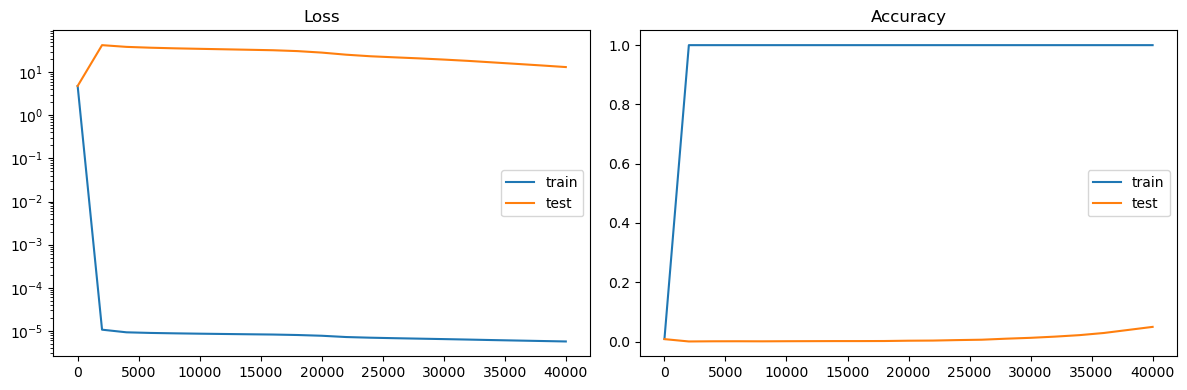

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses['epoch'], losses['train'], label='train')
axes[0].plot(losses['epoch'], losses['test'],  label='test')
axes[0].set_yscale('log'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(losses['epoch'], losses['train_acc'], label='train')
axes[1].plot(losses['epoch'], losses['test_acc'],  label='test')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Logit attribution (paper Section 5.1)

For each irrep $\rho$, build the tensor $X^\rho_{a,b,c} = \chi_\rho(ab c^{-1})$ and compute the cosine similarity between the flattened observed logits (also centered — see Appendix E.5 on "Centering") and the flattened character tensor. This is what they call **logit similarity**. "Key" representations are those with logit similarity > 0.005.

If the network has grokked via GCR, the observed logits should be a linear combination of characters from a small number of key irreps, and almost orthogonal to characters from the remaining irreps.

In [27]:
def build_character_tensor(grp, irrep_mats):
    """Given mats of shape (|G|, d, d), return X[a,b,c] = chi(a b c^{-1}).
    Uses the group's multiplication and inverse tables."""
    order = grp.order
    chi = np.trace(irrep_mats, axis1=1, axis2=2)  # (|G|,)
    mult = grp.mult_table.cpu().numpy()  # (|G|, |G|)
    inv = grp.inv_table.cpu().numpy()    # (|G|,)
    # X[a,b,c] = chi[ mult[ mult[a,b], inv[c] ] ]
    ab = mult                                               # (|G|, |G|)
    # build g = mult[ab[a,b], inv[c]]
    # easiest: for every (a,b), ab[a,b] is an index; then for every c, g = mult[ab[a,b], inv[c]]
    inv_c = inv  # (|G|,)
    # ab: (|G|, |G|).  reshape to (|G|, |G|, 1) and gather
    X = chi[mult[ab[:, :, None], inv_c[None, None, :]]]      # (|G|, |G|, |G|)
    return X

def all_logits_array(model, grp):
    """Return (|G|, |G|, |G|) tensor of logits over the full input grid, centered per (a,b)."""
    order = grp.order
    model.eval()
    with torch.no_grad():
        idx = torch.arange(order, device=device)
        A, B = torch.meshgrid(idx, idx, indexing='ij')
        logits = model(A.flatten(), B.flatten())  # (|G|^2, |G|)
        logits = logits.reshape(order, order, order).cpu().numpy()
    # centering: subtract mean over output axis (paper Appendix E.5)
    logits = logits - logits.mean(axis=2, keepdims=True)
    return logits

def logit_similarities(model, grp, irreps):
    L = all_logits_array(model, grp)                     # (|G|, |G|, |G|)
    L_flat = L.reshape(-1); L_norm = np.linalg.norm(L_flat)
    out = {}
    for name, (lam, mats) in irreps.items():
        if name == 'trivial':
            continue  # trivial is removed by centering
        X = build_character_tensor(grp, mats).astype(np.float64)
        X = X - X.mean(axis=2, keepdims=True)
        Xf = X.reshape(-1); Xn = np.linalg.norm(Xf)
        sim = float(np.dot(L_flat, Xf) / (L_norm * Xn + 1e-30))
        out[name] = sim
    return out

sims = logit_similarities(model, grp5, irreps)
for name, s in sorted(sims.items(), key=lambda x: -abs(x[1])):
    flag = ' <-- KEY' if abs(s) > 0.005 else ''
    print(f"{name:16s} logit similarity = {s:+.4f}{flag}")

sign             logit similarity = +0.4054 <-- KEY
standard         logit similarity = +0.1741 <-- KEY
5d_a             logit similarity = +0.0689 <-- KEY
5d_b             logit similarity = +0.0407 <-- KEY
standard_sign    logit similarity = +0.0298 <-- KEY
6d               logit similarity = +0.0146 <-- KEY


## 5. Embeddings and unembeddings in representation space (Section 5.2)

For each irrep $\rho$ of dimension $d$, the $|G|$ matrices $\rho(g)$ can be flattened to $d^2$ vectors in $\mathbb{R}^{|G|}$. The span of these vectors is the **representation space** of $\rho$ inside $\mathbb{R}^{|G|}$. By Peter-Weyl / Schur orthogonality, these subspaces across different irreps are orthogonal and direct-sum to all of $\mathbb{R}^{|G|}$.

For any embedding or unembedding matrix (which is some $|G| \times h$ tensor), we can project onto each representation subspace and compute the **fraction of variance explained** (FVE) by each irrep. If the GCR story is correct, FVE concentrates on the key irreps.

Flatten the irrep matrices into a $|G| \times d^2$ matrix $R$, orthonormalize via QR to get $\tilde R$, then $\tilde R^T W$ captures the representation-space component of $W$. The fraction of the squared Frobenius norm of $W$ captured is the FVE.

In [28]:
def rep_space_basis(mats):
    """Given mats of shape (|G|, d, d), return an orthonormal basis of the
    representation space inside R^|G|. Shape (|G|, rank)."""
    order, d, _ = mats.shape
    R = mats.reshape(order, d * d)  # (|G|, d^2)
    Q, _ = np.linalg.qr(R)
    # drop near-zero columns (shouldn't happen for a genuine irrep but just in case)
    keep = (np.linalg.norm(Q, axis=0) > 1e-8)
    return Q[:, keep]

def fve_by_irrep(W, irreps):
    """W: numpy array of shape (|G|, h). Returns dict {name: FVE}."""
    total = np.sum(W ** 2)
    out = {}
    for name, (lam, mats) in irreps.items():
        Q = rep_space_basis(mats)              # (|G|, r)
        proj = Q.T @ W                         # (r, h)
        out[name] = float(np.sum(proj ** 2) / (total + 1e-30))
    return out

# Extract W_a, W_b, W_U from the model as |G| x h tensors (following paper conventions).
# In my model, Wa() returns (hid, |G|), so transpose.
Wa_np = model.Wa().detach().cpu().numpy().T   # (|G|, hid)
Wb_np = model.Wb().detach().cpu().numpy().T
WU_np = model.WU().detach().cpu().numpy()     # (|G|, hid)  (U: hid -> |G|, so weight has shape (|G|, hid))

fve_Wa = fve_by_irrep(Wa_np, irreps)
fve_Wb = fve_by_irrep(Wb_np, irreps)
fve_WU = fve_by_irrep(WU_np, irreps)

print(f"{'irrep':16s} {'W_a':>8s} {'W_b':>8s} {'W_U':>8s}")
for name in irreps:
    print(f"{name:16s} {fve_Wa[name]*100:7.2f}% {fve_Wb[name]*100:7.2f}% {fve_WU[name]*100:7.2f}%")
print()
print("(paper Table 1 for S_5: sign ~6.95% / 9.58%, standard ~93% / 84.5% — after full training)")

irrep                 W_a      W_b      W_U
trivial             1.06%    0.92%    0.80%
standard           33.19%   32.46%   24.64%
5d_a               22.02%   21.59%   24.16%
6d                 12.63%   13.21%   18.54%
5d_b               15.26%   15.58%   18.41%
standard_sign       8.32%    8.69%    9.99%
sign                7.52%    7.56%    3.45%

(paper Table 1 for S_5: sign ~6.95% / 9.58%, standard ~93% / 84.5% — after full training)


## 6. MLP neurons implement $\rho(ab)$ (Section 5.3)

 For each neuron $i$ we look at its activation pattern across all $(a, b)$ inputs, giving a tensor of shape $(|G|, |G|)$. The paper defines a **hidden representation subspace** of rank $d^2$ inside $\mathbb{R}^{|G|^2}$ for each irrep, corresponding to the product $\rho(ab)$ viewed as a function of $(a, b)$. They also consider the subspaces corresponding to $\rho(a)$ and $\rho(b)$ (functions that depend only on one input).

Concretely, for irrep $\rho$:
- The $\rho(a)$-subspace is spanned by functions $f_{ij}(a, b) = \rho(a)_{ij}$, one for each $(i, j)$ pair — $d^2$ such functions.
- The $\rho(b)$-subspace, similarly, uses $g_{ij}(a, b) = \rho(b)_{ij}$.
- The $\rho(ab)$-subspace uses $h_{ij}(a, b) = \rho(ab)_{ij}$.

Each is a $d^2$-dimensional subspace of $\mathbb{R}^{|G|^2}$ (after centering). For each neuron we compute the FVE of its activation by each of these subspaces; aggregating across neurons in a cluster gives the summary in Table 2 of the paper.


In [29]:
def neuron_activations_full_grid(model, grp, batch_size=4096):
    """Return hidden activations across all (a, b) pairs as a (|G|^2, hid) numpy array.
    Centered by subtracting the mean over the batch dimension (per-neuron)."""
    order = grp.order
    model.eval()
    idx = torch.arange(order, device=device)
    A, B = torch.meshgrid(idx, idx, indexing='ij')
    Aflat = A.flatten(); Bflat = B.flatten()
    out = []
    with torch.no_grad():
        for s in range(0, order*order, batch_size):
            _, h, _ = model(Aflat[s:s+batch_size], Bflat[s:s+batch_size], return_hidden=True)
            out.append(h.cpu().numpy())
    H = np.concatenate(out, axis=0)       # (|G|^2, hid)
    H = H - H.mean(axis=0, keepdims=True) # center per neuron
    return H

def rho_a_subspace(mats):
    """Basis for the subspace of R^(|G|^2) spanned by (a,b) -> rho(a)_{ij}.
    Returns shape (|G|^2, d^2) orthonormalized."""
    order, d, _ = mats.shape
    # f_{ij}(a,b) = rho(a)_{ij}, independent of b
    # build (|G|, |G|, d, d): f[a,b,i,j] = mats[a,i,j]
    f = np.broadcast_to(mats[:, None, :, :], (order, order, d, d)).copy()
    # flatten the (d,d) basis directions
    M = f.reshape(order * order, d * d)
    # center each column over the |G|^2 axis
    M = M - M.mean(axis=0, keepdims=True)
    Q, _ = np.linalg.qr(M)
    keep = np.linalg.norm(Q, axis=0) > 1e-8
    return Q[:, keep]

def rho_b_subspace(mats):
    order, d, _ = mats.shape
    f = np.broadcast_to(mats[None, :, :, :], (order, order, d, d)).copy()
    M = f.reshape(order * order, d * d)
    M = M - M.mean(axis=0, keepdims=True)
    Q, _ = np.linalg.qr(M)
    keep = np.linalg.norm(Q, axis=0) > 1e-8
    return Q[:, keep]

def rho_ab_subspace(mats, grp):
    """Basis for R^(|G|^2) spanned by (a,b) -> rho(ab)_{ij}."""
    order, d, _ = mats.shape
    mult = grp.mult_table.cpu().numpy()  # (|G|, |G|)
    # mats_ab[a,b] = mats[ mult[a,b] ]
    f = mats[mult]                       # (|G|, |G|, d, d)
    M = f.reshape(order * order, d * d)
    M = M - M.mean(axis=0, keepdims=True)
    Q, _ = np.linalg.qr(M)
    keep = np.linalg.norm(Q, axis=0) > 1e-8
    return Q[:, keep]

def neuron_fve_by_subspace(H, Q):
    """H: (|G|^2, hid), Q: (|G|^2, r) orthonormal.
    Returns (hid,) vector of FVEs per neuron."""
    norms = (H ** 2).sum(axis=0) + 1e-30    # (hid,)
    proj = Q.T @ H                          # (r, hid)
    proj_norms = (proj ** 2).sum(axis=0)
    return proj_norms / norms

In [30]:
H = neuron_activations_full_grid(model, grp5)
print("hidden activation grid shape:", H.shape)

# Aggregate FVE statistics per irrep
rows = []
for name, (lam, mats) in irreps.items():
    if name == 'trivial':
        continue  # trivial is killed by centering
    Qa  = rho_a_subspace(mats)
    Qb  = rho_b_subspace(mats)
    Qab = rho_ab_subspace(mats, grp5)
    fve_a  = neuron_fve_by_subspace(H, Qa)
    fve_b  = neuron_fve_by_subspace(H, Qb)
    fve_ab = neuron_fve_by_subspace(H, Qab)
    rows.append((name, fve_a.mean(), fve_b.mean(), fve_ab.mean(),
                 (fve_a + fve_b + fve_ab).mean()))

print(f"{'irrep':16s} {'rho(a)':>10s} {'rho(b)':>10s} {'rho(ab)':>10s} {'sum':>10s}")
for name, fa, fb, fab, s in rows:
    print(f"{name:16s} {fa*100:9.2f}% {fb*100:9.2f}% {fab*100:9.2f}% {s*100:9.2f}%")

print()
print("(paper Table 2 for S_5, fully grokked: sign neurons ~33%/33%/33%; standard neurons ~39.6%/37.1%/11.3%)")
print("If everything sums to near 0% below, the model has not grokked and you need more epochs.")

hidden activation grid shape: (14400, 128)
irrep                rho(a)     rho(b)    rho(ab)        sum
standard              9.97%      9.47%      0.67%     20.11%
5d_a                 10.37%     10.59%      0.36%     21.32%
6d                    7.76%      8.04%      0.06%     15.86%
5d_b                  8.42%      8.14%      0.22%     16.78%
standard_sign         4.20%      4.49%      0.14%      8.84%
sign                  0.76%      0.72%      0.52%      1.99%

(paper Table 2 for S_5, fully grokked: sign neurons ~33%/33%/33%; standard neurons ~39.6%/37.1%/11.3%)
If everything sums to near 0% below, the model has not grokked and you need more epochs.


## 7. Ablations (Section 5.5)

Two kinds of ablations:

1. **Excluded loss**: project the hidden activations onto the *complement* of the key representations' $\rho(ab)$ subspace. This removes the generalizing circuit and leaves only the memorizing circuit. Evaluated on train data.
2. **Restricted loss**: project the hidden activations onto *only* the key representations' $\rho(ab)$ subspace. This keeps only the GCR circuit. Evaluated on test data.

If the GCR story is correct:
- Ablating to only $\rho(ab)$ in key irreps (restricted) should give loss similar to or lower than test loss.
- Excluded loss should be high on test (because the GCR circuit has been removed).

In [32]:
def ablation_losses(model, grp, data, key_irreps, irreps):
    """Compute restricted and excluded loss by projecting hidden activations.

    key_irreps: list of irrep names whose rho(ab) subspaces we keep.
    """
    model.eval()
    order = grp.order

    # Build the union basis of rho(ab) subspaces across key irreps
    Q_list = []
    for name in key_irreps:
        mats = irreps[name][1]
        Q_list.append(rho_ab_subspace(mats, grp))
    Q_key = np.concatenate(Q_list, axis=1)  # (|G|^2, sum of ranks)
    # Re-orthonormalize just in case
    Q_key, _ = np.linalg.qr(Q_key)

    # Project. We need: for each (a,b) pair, the projected hidden activation.
    # Strategy: compute H on the full grid, project, reshape back, then lookup by (a,b).
    H = neuron_activations_full_grid(model, grp)  # (|G|^2, hid), centered
    H_mean_over_ab = H.mean(axis=0, keepdims=True)  # 0 after centering, but keep for clarity

    # restricted: H projected onto Q_key only
    H_restricted = Q_key @ (Q_key.T @ H)  # (|G|^2, hid)
    # excluded: H minus that projection
    H_excluded = H - H_restricted

    # Re-add the per-neuron mean to replicate original scale (we centered earlier)
    # Actually the raw hidden H_raw had per-neuron mean. When we project the centered
    # H onto a subspace and feed back through U, we're measuring the contribution
    # of that subspace alone. To reconstruct "full" logits we add the mean back.
    with torch.no_grad():
        idx = torch.arange(order, device=device)
        A, B = torch.meshgrid(idx, idx, indexing='ij')
        _, H_raw, _ = model(A.flatten(), B.flatten(), return_hidden=True)
        mean_raw = H_raw.mean(dim=0, keepdim=True).cpu().numpy()
    H_restricted_full = H_restricted + mean_raw
    H_excluded_full = H_excluded + mean_raw

    WU_t = model.WU().detach().cpu().numpy()  # (|G|, hid)
    logits_res = (H_restricted_full @ WU_t.T).reshape(order, order, order)
    logits_exc = (H_excluded_full @ WU_t.T).reshape(order, order, order)

    def evaluate(logits_arr, pairs, targets):
        p = pairs.cpu().numpy(); t = targets.cpu().numpy()
        L = logits_arr[p[:, 0], p[:, 1]]         # (N, |G|)
        L_t = torch.tensor(L, dtype=torch.float32)
        t_t = torch.tensor(t, dtype=torch.long)
        return F.cross_entropy(L_t, t_t).item()

    restricted_loss_test = evaluate(logits_res, data['X_test'], data['Y_test'])
    excluded_loss_train  = evaluate(logits_exc, data['X_train'], data['Y_train'])
    with torch.no_grad():
        te_logits = model(data['X_test'][:, 0].long(), data['X_test'][:, 1].long())
        baseline_loss_test = F.cross_entropy(te_logits, data['Y_test'].long()).item()
        tr_logits = model(data['X_train'][:, 0].long(), data['X_train'][:, 1].long())
        baseline_loss_train = F.cross_entropy(tr_logits, data['Y_train'].long()).item()

    return {
        'baseline_test_loss':   baseline_loss_test,
        'baseline_train_loss':  baseline_loss_train,
        'restricted_test_loss': restricted_loss_test,
        'excluded_train_loss':  excluded_loss_train,
    }

In [33]:
# Pick key irreps based on logit similarity (threshold 0.005 as in paper)
key = [name for name, s in sims.items() if abs(s) > 0.005]
print("key irreps by logit similarity:", key)
if len(key) == 0:
    # fallback so the ablation cell still runs
    key = ['sign', 'standard']
    print("none exceeded threshold — using default ['sign', 'standard'] for the ablation")

abl = ablation_losses(model, grp5, data, key, irreps)
for k, v in abl.items():
    print(f"{k:30s} = {v:.4e}")

key irreps by logit similarity: ['standard', '5d_a', '6d', '5d_b', 'standard_sign', 'sign']
baseline_test_loss             = 1.3149e+01
baseline_train_loss            = 5.6713e-06
restricted_test_loss           = 2.9553e-03
excluded_train_loss            = 4.3775e+00


### Tests the GCR algorithm's prediction.

**Setup.** Fix an output class $c$. The logits form a function on $G \times G$:
$$L_c(a, b) = \text{logit}_c(a, b)$$

We apply a **two-sided group Fourier transform** — Fourier transform on $a$ using irrep $\rho$, on $b$ using irrep $\sigma$:
$$\hat L_c(\rho, \sigma)_{(i,k),(j,l)} = \sum_{a, b} L_c(a, b) \, \rho(a)_{ij} \, \sigma(b)_{kl}$$

This is a $d_\rho d_\sigma \times d_\rho d_\sigma$ tensor for each pair of irreps. We summarize it by its Frobenius norm squared,
$$P(\rho, \sigma) = \|\hat L_c(\rho, \sigma)\|_F^2$$

giving one scalar per irrep pair. We visualize as a heatmap where row $i$ is irrep $\rho$, column $j$ is irrep $\sigma$.

 The sum splits: $\hat L_c(\rho, \sigma)_{(i,k),(j,l)} = \sum_a \rho(a)_{ij} \left(\sum_b L_c(a,b) \sigma(b)_{kl}\right)$. We first contract $b$ (an `einsum` over the $b$-axis with $\sigma$), then contract $a$. 

**The GCR prediction.** Logits at output $c$ are a sum of characters $\chi_\rho(abc^{-1})$ over key irreps. Expanding $\chi_\rho(abc^{-1}) = \text{tr}(\rho(a)\rho(b)\rho(c^{-1}))$, this is a function of $(a, b)$ whose two-sided Fourier transform is **zero except when $\rho = \sigma$**. So under GCR:

- The heatmap should be **diagonal-dominated**: $P(\rho, \rho)$ large, $P(\rho, \sigma)$ near zero for $\rho \ne \sigma$.
- Only a **small number of diagonal entries** should be large.

We print the ratio of diagonal power to total power as a scalar summary.

- **No structure**: random weights give ratio $\approx 1/n_{\text{irreps}} \approx 0.17$.
- **Pure GCR in theory**: ratio = 1.0.
- **Pure GCR in practice**: ratio $\approx$ 0.7–0.9. The paper notes (Section 5.3 and Appendix E.3) that networks implement the matrix multiplication $\rho(a)\rho(b) \to \rho(ab)$ only *approximately* using ReLUs, and the residual error puts some power back into $\rho(a)$-only and $\rho(b)$-only terms. Those show up as off-diagonal entries, so the diagonal ratio doesn't reach 1.0 even on a fully grokked model.

So "close to 1" isn't the right expectation — "substantially larger than 0.17" is. 


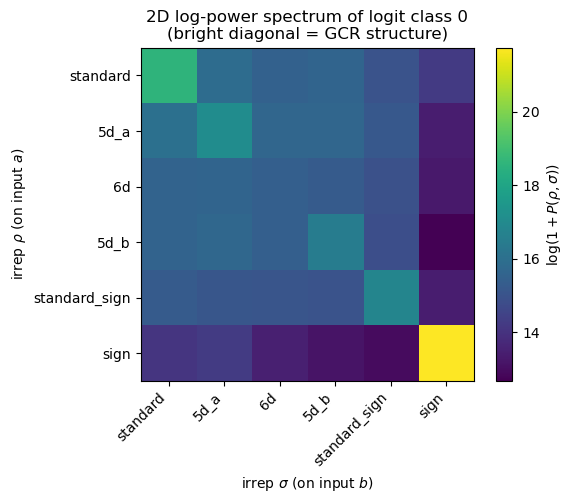

diagonal power (rho == sigma): 2.941e+09
off-diagonal power:            1.109e+08
ratio diag / total:            0.9637

Interpretation of the ratio:
  - No structure (random weights):  ~0.167  (uniform across pairs)
  - Pure GCR (impossible target):    1.000
  - Real grokked model:             ~0.7-0.9 (the network implements rho(a)rho(b)->rho(ab)
                                              only approximately via ReLU, leaving
                                              residual off-diagonal power)


In [34]:
def logit_2d_power(L_c, irreps_list):
    """Compute P(rho, sigma) = ||L_hat(rho, sigma)||_F^2 for every pair of irreps.

    L_c: (|G|, |G|) logit surface for a fixed output class.
    irreps_list: list of (name, (partition, mats)) pairs; mats has shape (|G|, d, d).
    Returns: (n_irreps, n_irreps) numpy array of powers.
    """
    n = len(irreps_list)
    P = np.zeros((n, n))
    for i, (ni, (lam_i, mi)) in enumerate(irreps_list):
        for j, (nj, (lam_j, mj)) in enumerate(irreps_list):
            # Step 1: contract over a. U[i_r, j_r, b] = sum_a mi[a, i_r, j_r] * L[a, b]
            U = np.einsum('aij,ab->ijb', mi, L_c)
            # Step 2: contract over b. Lhat[i_r, j_r, k_r, l_r] = sum_b U[i_r, j_r, b] * mj[b, k_r, l_r]
            Lhat = np.einsum('ijb,bkl->ijkl', U, mj)
            P[i, j] = float(np.sum(Lhat ** 2))
    return P

# Build full (|G|, |G|, |G|) logit tensor, centered on output axis (paper App. E.5).
L_arr = all_logits_array(model, grp5)

# Pick an output class. Class 0 is conventional; GCR structure should hold for any c.
c = 0
L_c = L_arr[:, :, c]   # (|G|, |G|) logit surface for class c

# Exclude trivial irrep — its contribution is zero after centering anyway.
irreps_list = [(n, v) for n, v in irreps.items() if n != 'trivial']
irrep_names = [n for n, _ in irreps_list]

P2d = logit_2d_power(L_c, irreps_list)

# Plot on log scale to compress dynamic range; log1p handles zeros gracefully.
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.log1p(P2d), cmap='viridis')
ax.set_xticks(range(len(irrep_names))); ax.set_yticks(range(len(irrep_names)))
ax.set_xticklabels(irrep_names, rotation=45, ha='right')
ax.set_yticklabels(irrep_names)
ax.set_xlabel(r'irrep $\sigma$ (on input $b$)')
ax.set_ylabel(r'irrep $\rho$ (on input $a$)')
ax.set_title(f'2D log-power spectrum of logit class {c}\n(bright diagonal = GCR structure)')
plt.colorbar(im, label=r'$\log(1 + P(\rho, \sigma))$')
plt.tight_layout(); plt.show()

# Scalar summary: what fraction of total power sits on the diagonal?
diag_power = np.trace(P2d)
off_power = P2d.sum() - diag_power
print(f'diagonal power (rho == sigma): {diag_power:.3e}')
print(f'off-diagonal power:            {off_power:.3e}')
print(f'ratio diag / total:            {diag_power / (diag_power + off_power):.4f}')
print()
print('Interpretation of the ratio:')
print(f'  - No structure (random weights):  ~{1/len(irreps_list):.3f}  (uniform across pairs)')
print( '  - Pure GCR (impossible target):    1.000')
print( '  - Real grokked model:             ~0.7-0.9 (the network implements rho(a)rho(b)->rho(ab)')
print( '                                              only approximately via ReLU, leaving')
print( '                                              residual off-diagonal power)')
